**Telco Customer Churn Analysis using Python**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Display all columns
pd.set_option('display.max_columns',None)

**Project Overview**

In [4]:
df = pd.read_csv("telco_customer_churn_data.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Data Understanding**

In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

**Churn Distribution**

In [11]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

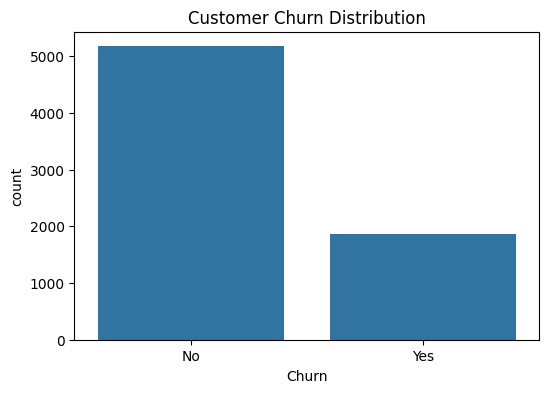

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn',data=df)
plt.title('Customer Churn Distribution')
plt.show()

### Business Insight

• Out of 7,043 customers, 26.54% (1,869) churned.
• 73.46% (5,174) customers remained active.
• More than one-fourth of customers left the company, indicating a significant retention challenge.

**Univariate Analysis**

**Gender Distribution**

In [13]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

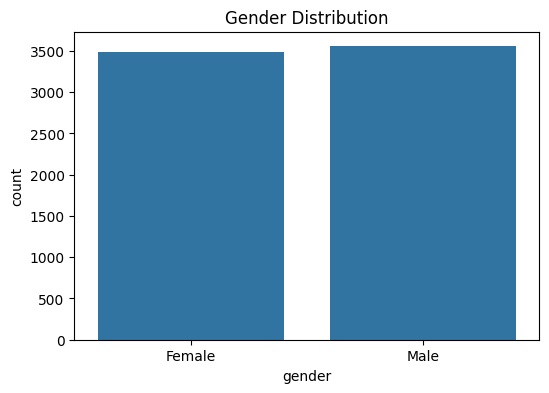

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender',data=df)
plt.title('Gender Distribution')
plt.show()

**Contract Distribution**

In [15]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

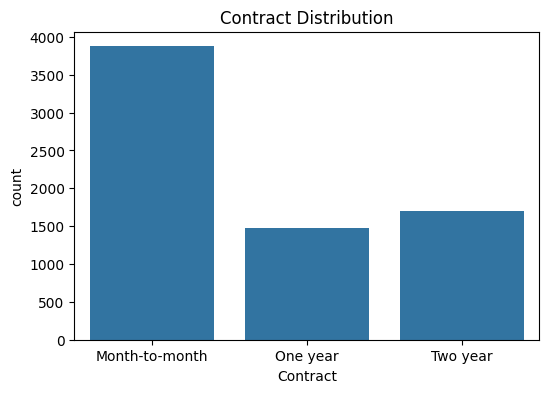

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract',data=df)
plt.title('Contract Distribution')
plt.show()

**Internet Service Distribution**

In [17]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

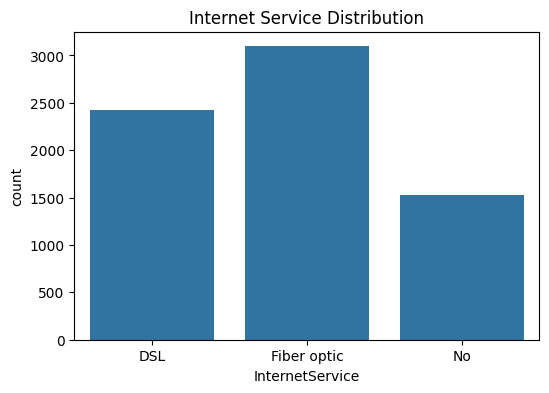

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', data=df)
plt.title('Internet Service Distribution')
plt.show()

**Payment Method Distribution**

In [19]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

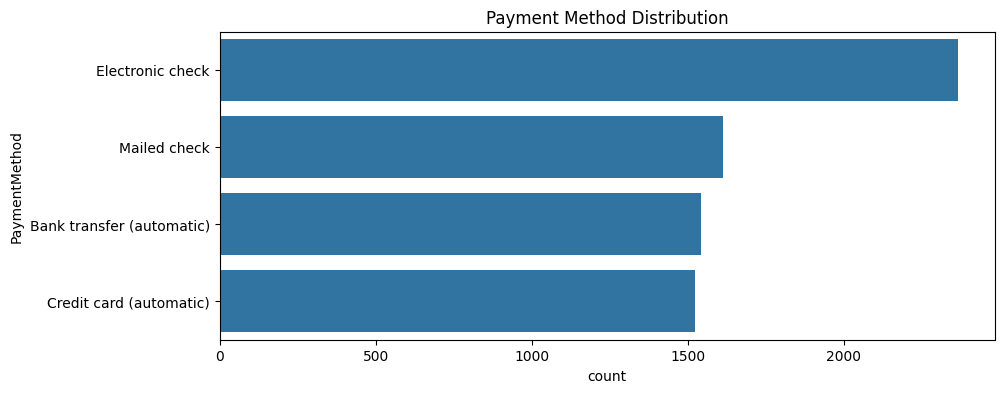

In [20]:
plt.figure(figsize=(10,4))
sns.countplot(y='PaymentMethod', data=df)
plt.title('Payment Method Distribution')
plt.show()

**Senior Citizen Distribution**

In [21]:
df['SeniorCitizenStatus'] = df['SeniorCitizen'].map({
    0:'No',
    1:'Yes'
})

In [22]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

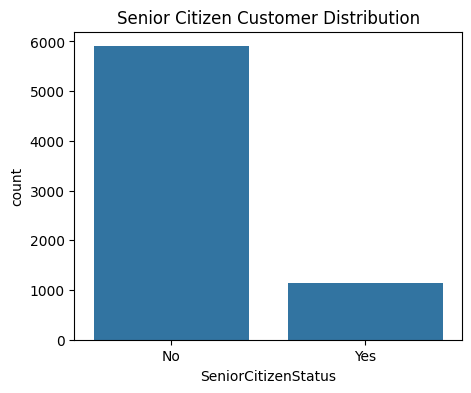

In [23]:
plt.figure(figsize=(5,4))
sns.countplot(x='SeniorCitizenStatus', data=df)
plt.title('Senior Citizen Customer Distribution')
plt.show()

**Tenure Distribution**

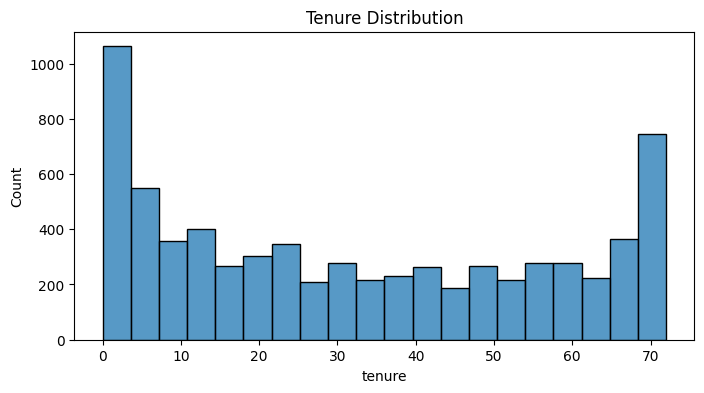

In [24]:
plt.figure(figsize=(8,4))
sns.histplot(df['tenure'], bins=20)
plt.title('Tenure Distribution')
plt.show()

**Bivariate Analysis**

**Contract vs Churn**

In [25]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


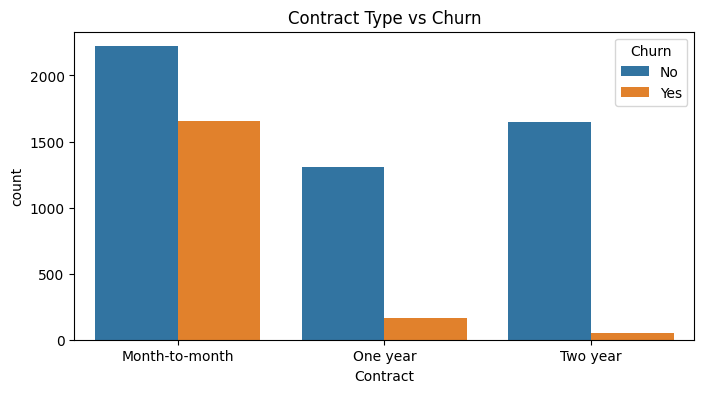

In [26]:
plt.figure(figsize=(8,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.show()

### Business Insight

- Month-to-month customers have the highest churn.
- Two-year contract customers have the lowest churn.
- Longer contract commitments improve customer retention.

**Internet Service vs Churn**

In [27]:
pd.crosstab(df['InternetService'], df['Churn'])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


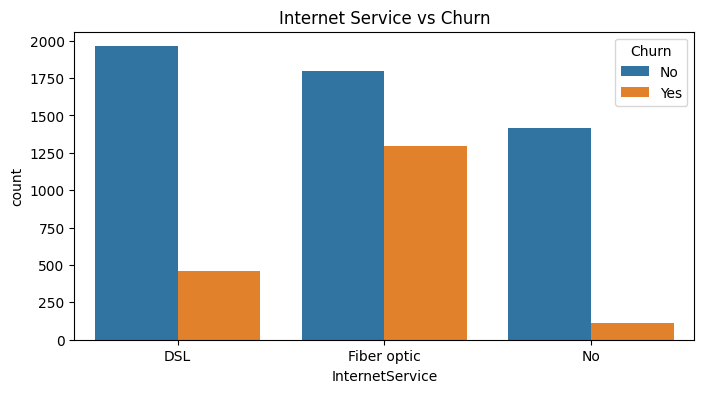

In [28]:
plt.figure(figsize=(8,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Internet Service vs Churn')
plt.show()

### Business Insight

- Fiber optic customers show higher churn than DSL customers.
- Service quality and pricing should be investigated.

**Payment Method vs Churn**

In [29]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


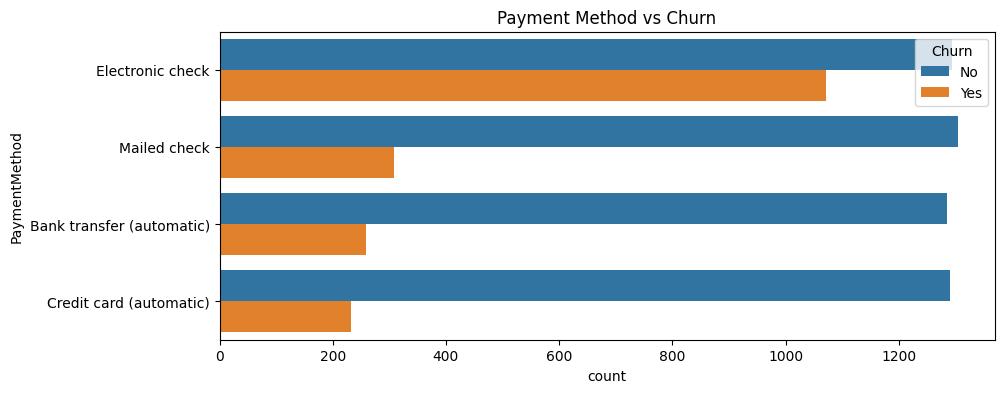

In [30]:
plt.figure(figsize=(10,4))
sns.countplot(y='PaymentMethod', hue='Churn', data=df)
plt.title('Payment Method vs Churn')
plt.show()

### Business Insight

- Electronic check customers have the highest churn.
- Automatic payment methods are associated with better retention.

**Tech Support vs Churn**

In [31]:
pd.crosstab(df['TechSupport'], df['Churn'])

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


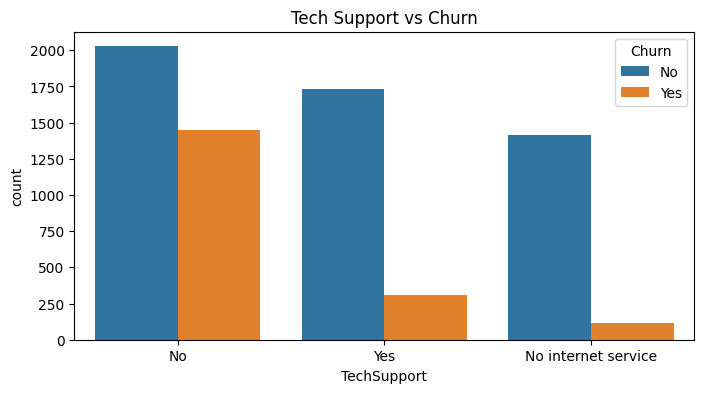

In [32]:
plt.figure(figsize=(8,4))
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title('Tech Support vs Churn')
plt.show()

### Business Insight

- Customers without Tech Support are more likely to churn.
- Providing support services can improve retention.

**Senior Citizen vs Churn**

In [33]:
df['SeniorCitizenStatus'] = df['SeniorCitizen'].map({
    0:'No',
    1:'Yes'
})

In [34]:
pd.crosstab(df['SeniorCitizen'], df['Churn'])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


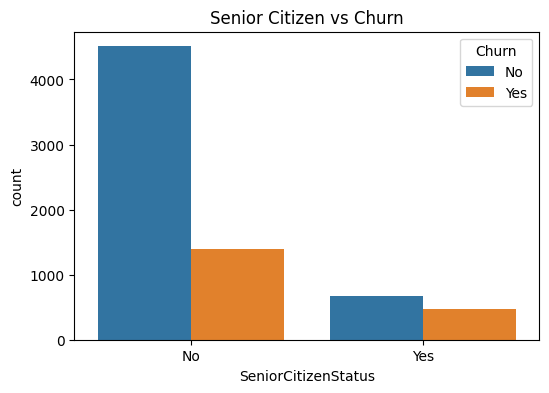

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizenStatus', hue='Churn', data=df)
plt.title('Senior Citizen vs Churn')
plt.show()

### Business Insight

• Senior citizens have a higher churn tendency compared to non-senior citizens.
• Although senior citizens represent a smaller customer segment, a significant proportion of them have churned.
• Non-senior citizens form the majority of the customer base and show better retention.
• Targeted retention programs and personalized support for senior citizens may help reduce churn.

**Numerical Analysis**

In [36]:
df['TotalCharges'].dtype

dtype('O')

In [37]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [38]:
df['TotalCharges'].dtype

dtype('float64')

In [39]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [40]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [41]:
df['TotalCharges'].isnull().sum()

np.int64(0)

### Data Quality Check

During numerical analysis, the TotalCharges column was found to be stored as an object datatype instead of a numeric datatype. The column was converted to numeric format, and 11 missing values generated during conversion were imputed using the median value.

In [42]:
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


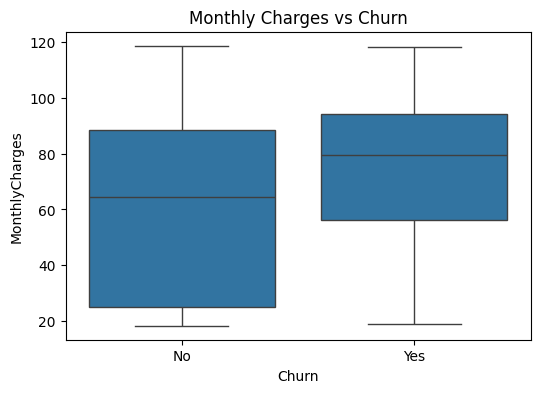

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

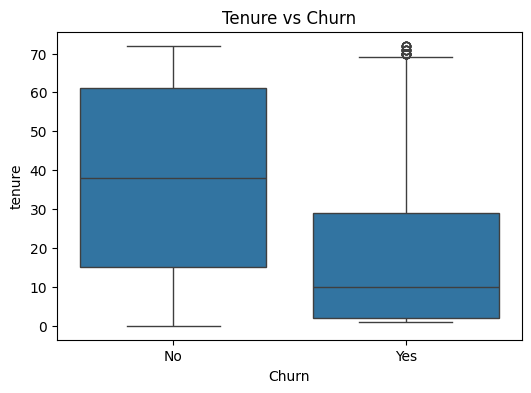

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

**Correlation Heatmap**

In [45]:
df_corr = df[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']]
corr = df_corr.corr()
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102652
tenure,0.016567,1.000000,0.247900,0.825464
MonthlyCharges,0.220173,0.247900,1.000000,0.650864
TotalCharges,0.102652,0.825464,0.650864,1.000000


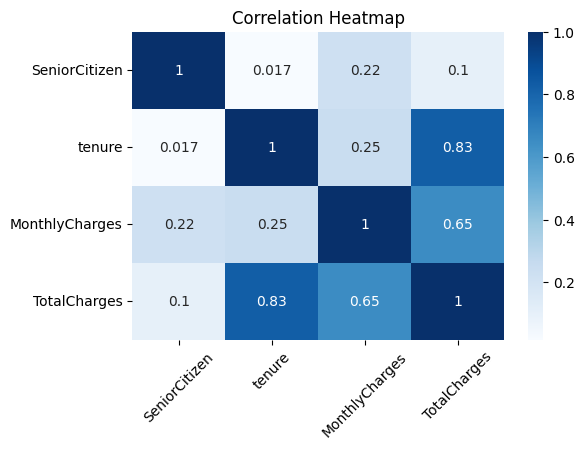

In [48]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.xticks(rotation=45)
plt.show()

**Total Charges vs Churn**

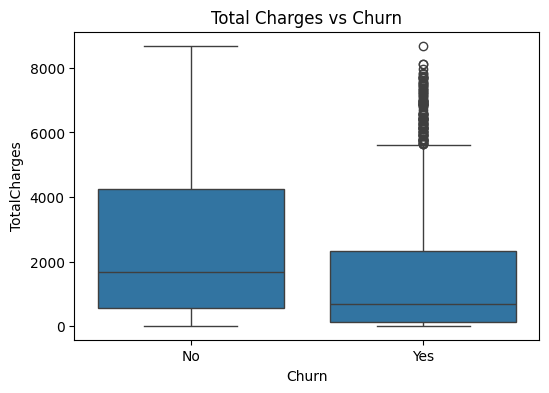

In [47]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title('Total Charges vs Churn')
plt.show()

### Business Insight

- Higher monthly charges are associated with increased churn.
- Customers with longer tenure generate higher revenue.
- Total Charges strongly correlate with tenure (0.83).

# Executive Summary

## Key Findings

1. Churn Rate: 26.54%
2. Month-to-Month contracts have highest churn.
3. Electronic Check customers have highest churn.
4. Customers without Tech Support are at greater risk.
5. New customers churn more frequently.

## Recommendations

1. Encourage long-term contracts.
2. Improve Tech Support adoption.
3. Investigate Fiber Optic customer dissatisfaction.
4. Promote automatic payment methods.
5. Focus retention efforts on new customers.